# East River HRU Quicklook (Direct Plotting)

This notebook now uses direct shapefile plotting for QA.

Workflow:
1. Load config and shapefiles.
2. Plot raw HRU classes directly from hru_gdf.
3. Plot raw soil/land intersection classes directly from soil_gdf and land_gdf.
4. Show a compact HRU ordering check table (HRU_ID, elevClass, aspect).

Use after running:
`conda run -n ess-project-env python ess-project/modeling/04-distributed/run_east_river_distributed_workflow_light.py --config ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml --preset minimal`

In [1]:
from pathlib import Path
import sys

import geopandas as gpd
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
import yaml

# Point to the repo root so local imports below are stable when run from VS Code.
REPO_ROOT = Path('/home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro')
if str(REPO_ROOT) not in sys.path:
    sys.path.append(str(REPO_ROOT))

# Change this to your active distributed config when needed.
CONFIG_PATH = REPO_ROOT / 'ess-project' / '0_config_files' / 'config_East_River_distributed_elevAspect.yaml'

# Optional: set to True to regenerate HRU diagnostics CSV if missing.
AUTO_EXPORT_IF_MISSING = False

# Optional: set to True to always rebuild the HRU diagnostics CSV for fresh notebook reads.
FORCE_SUMMARY_REFRESH = True

# Optional continuous elevation bins for CSV export. Leave empty string to skip.
EXPORT_ELEVATION_BANDS = ''  # example: '2500,2800,3100,3400'

plt.style.use('default')
%matplotlib inline
print(f'Using config: {CONFIG_PATH}')

Using config: /home/dlhogan/projects/forked-repos/CONFLUENCE-uwmtnhydro/ess-project/0_config_files/config_East_River_distributed_elevAspect.yaml


In [2]:
# Keep helper code short and explicit so debugging is easy.
# Import helper script directly from its file path because this folder name has hyphens.
import importlib.util
import re

export_script = REPO_ROOT / 'ess-project' / 'modeling' / '04-distributed' / 'export_hru_attributes.py'
spec = importlib.util.spec_from_file_location('export_hru_attributes', export_script)
mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(mod)
export_hru_tables = mod.export_hru_tables

def load_config(path: Path) -> dict:
    with path.open('r', encoding='utf-8') as fp:
        return yaml.safe_load(fp) or {}


def project_dir_from_config(cfg: dict) -> Path:
    return Path(cfg['CONFLUENCE_DATA_DIR']) / f"domain_{cfg['DOMAIN_NAME']}"


def resolve_hru_shapefile(cfg: dict, project_dir: Path) -> Path:
    # Use explicit CATCHMENT_SHP_NAME when provided.
    name = cfg.get('CATCHMENT_SHP_NAME', 'default')
    if name == 'default' or not name:
        method = str(cfg.get('DOMAIN_DISCRETIZATION', 'GRUs')).replace(',', '_')
        name = f"{cfg['DOMAIN_NAME']}_HRUs_{method}.shp"

    # Keep path logic transparent: default project path unless overridden.
    catchment_path = cfg.get('CATCHMENT_PATH', 'default')
    if catchment_path == 'default' or not catchment_path:
        shp_dir = project_dir / 'shapefiles' / 'catchment'
    else:
        shp_dir = Path(catchment_path)
    return shp_dir / name


def diagnostics_dir(project_dir: Path) -> Path:
    return project_dir / 'diagnostics' / 'hru_attributes'


def resolve_intersection_shapefiles(cfg: dict, project_dir: Path) -> tuple[Path, Path]:
    soil_dir = cfg.get('INTERSECT_SOIL_PATH', 'default')
    if soil_dir == 'default' or not soil_dir:
        soil_dir = project_dir / 'shapefiles' / 'catchment_intersection' / 'with_soilgrids'
    else:
        soil_dir = Path(soil_dir)

    soil_name = cfg.get('INTERSECT_SOIL_NAME', 'catchment_with_soilclass.shp')
    if soil_name == 'default' or not soil_name:
        soil_name = 'catchment_with_soilclass.shp'
    soil_shp = soil_dir / soil_name

    land_dir = cfg.get('INTERSECT_LAND_PATH', 'default')
    if land_dir == 'default' or not land_dir:
        land_dir = project_dir / 'shapefiles' / 'catchment_intersection' / 'with_landclass'
    else:
        land_dir = Path(land_dir)

    land_name = cfg.get('INTERSECT_LAND_NAME', 'catchment_with_landclass.shp')
    if land_name == 'default' or not land_name:
        land_name = 'catchment_with_landclass.shp'
    land_shp = land_dir / land_name

    return soil_shp, land_shp


def resolve_summa_table_path(cfg: dict, project_dir: Path, table_name: str) -> Path:
    settings_dir = cfg.get('SETTINGS_SUMMA_PATH', 'default')
    if settings_dir == 'default' or not settings_dir:
        settings_dir = project_dir / 'settings' / 'SUMMA'
    else:
        settings_dir = Path(settings_dir)

    candidates = [
        Path(settings_dir) / table_name,
        REPO_ROOT / 'ess-project' / '0_base_settings' / 'SUMMA' / table_name,
        REPO_ROOT / '0_base_settings' / 'SUMMA' / table_name,
    ]

    for candidate in candidates:
        if candidate.exists():
            return candidate

    raise FileNotFoundError(f'Could not find {table_name} in expected locations')


def parse_summa_class_lookup(table_path: Path, section_name: str) -> dict[int, str]:
    lines = table_path.read_text(encoding='utf-8').splitlines()
    in_section = False
    lookup: dict[int, str] = {}

    for raw_line in lines:
        line = raw_line.strip()
        if not line:
            continue

        if line == section_name:
            in_section = True
            continue

        if not in_section:
            continue

        if line.startswith('TOPT_DATA'):
            break

        # Match class records like:
        # 12, ... 'Barren Tundra'   OR   3 ... 'LOAM'
        match = re.match(r'^\s*(\d+)\s*,?\s+.*\'([^\']+)\'\s*$', raw_line)
        if not match:
            continue

        class_id = int(match.group(1))
        class_name = match.group(2).strip()
        lookup[class_id] = class_name

    return lookup


def load_rosetta_soil_lookup(cfg: dict, project_dir: Path) -> dict[int, str]:
    table = resolve_summa_table_path(cfg, project_dir, 'TBL_SOILPARM.TBL')
    return parse_summa_class_lookup(table, 'ROSETTA')


def load_modis_land_lookup(cfg: dict, project_dir: Path) -> dict[int, str]:
    table = resolve_summa_table_path(cfg, project_dir, 'TBL_VEGPARM.TBL')
    return parse_summa_class_lookup(table, 'MODIFIED_IGBP_MODIS_NOAH')


def dominant_class_from_columns(df: gpd.GeoDataFrame, prefixes: list[str]) -> tuple[pd.Series, list[str]]:
    class_cols = [
        col for col in df.columns
        if any(col.startswith(prefix) for prefix in prefixes)
    ]
    if not class_cols:
        return pd.Series(pd.array([pd.NA] * len(df), dtype='Int64'), index=df.index), class_cols

    numeric = df[class_cols].apply(pd.to_numeric, errors='coerce').fillna(0.0)
    dominant_col = numeric.idxmax(axis=1)
    dominant_id = dominant_col.str.extract(r'(\d+)$')[0].astype('Int64')
    return dominant_id, class_cols

In [3]:
cfg = load_config(CONFIG_PATH)
project_dir = project_dir_from_config(cfg)
hru_shp = resolve_hru_shapefile(cfg, project_dir)
soil_intersection_shp, land_intersection_shp = resolve_intersection_shapefiles(cfg, project_dir)

if not hru_shp.exists():
    raise FileNotFoundError(f'HRU shapefile not found: {hru_shp}')

hru_gdf = gpd.read_file(hru_shp)
soil_gdf = gpd.read_file(soil_intersection_shp) if soil_intersection_shp.exists() else None
land_gdf = gpd.read_file(land_intersection_shp) if land_intersection_shp.exists() else None

# Handle shapefile field-name truncation gracefully.
if 'aspectClass' not in hru_gdf.columns and 'aspectClas' in hru_gdf.columns:
    hru_gdf['aspectClass'] = pd.to_numeric(hru_gdf['aspectClas'], errors='coerce').astype('Int64')

print(f'HRU shapefile: {hru_shp}')
print(f'HRU count: {len(hru_gdf)}')
print('HRU columns:', sorted(hru_gdf.columns.tolist()))
print(f'Soil intersection shapefile: {soil_intersection_shp} (exists={soil_intersection_shp.exists()})')
print(f'Land intersection shapefile: {land_intersection_shp} (exists={land_intersection_shp.exists()})')

if soil_gdf is not None:
    print('Soil columns:', sorted(soil_gdf.columns.tolist()))
if land_gdf is not None:
    print('Land columns:', sorted(land_gdf.columns.tolist()))

# Keep a clean plotting copy for direct maps.
plot_gdf = hru_gdf.copy()

HRU shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment/East_River_distributed_elevAspect_HRUs_elevation_aspect.shp
HRU count: 25
HRU columns: ['GRU_ID', 'GRU_area', 'HRU_ID', 'HRU_area', 'ID', 'aspectClas', 'aspectClass', 'center_lat', 'center_lon', 'combined_e', 'elevClass', 'elev_mean', 'geometry', 'gru_to_seg', 'hru_type', 'slope_mean']
Soil intersection shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment_intersection/with_soilgrids/catchment_with_soilclass.shp (exists=True)
Land intersection shapefile: /scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/shapefiles/catchment_intersection/with_landclass/catchment_with_landclass.shp (exists=True)
Soil columns: ['GRU_ID', 'GRU_area', 'HRU_ID', 'HRU_area', 'ID', 'USGS_0', 'USGS_12', 'USGS_2', 'USGS_3', 'USGS_7', 'USGS_8', 'USGS_P0', 'USGS_P12', 'USGS_P2', 'USGS_P3', 'USGS_P7', 'USGS_P8', 'aspectClas', 'ce

In [4]:
# Translate soil and land class IDs to SUMMA table names (ROSETTA and MODIS).

def _first_existing(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None

hru_id_col = _first_existing(hru_gdf.columns, ['HRU_ID', 'hru_id', 'HruId'])
if hru_id_col is None:
    raise KeyError('Could not find HRU ID column in hru_gdf')

rosetta_lookup = load_rosetta_soil_lookup(cfg, project_dir)
modis_lookup = load_modis_land_lookup(cfg, project_dir)

print(f'Loaded ROSETTA classes: {len(rosetta_lookup)}')
print(f'Loaded MODIS classes: {len(modis_lookup)}')

# Start from HRU table and attach translated dominant soil/land class labels.
simple_gdf = hru_gdf.copy()

# Ensure stable output names even if prior notebook state already had these fields.
for col in ['soilClass', 'soil_name', 'landClass', 'land_name', 'soilClass_x', 'soilClass_y', 'landClass_x', 'landClass_y']:
    if col in simple_gdf.columns:
        simple_gdf = simple_gdf.drop(columns=[col])

# Soil translation.
if soil_gdf is not None and 'soilClass' in soil_gdf.columns and hru_id_col in soil_gdf.columns:
    soil_keep = [hru_id_col, 'soilClass']
    if 'soilPct' in soil_gdf.columns:
        soil_keep.append('soilPct')

    soil_join = soil_gdf[soil_keep].copy()
    soil_join['soilClass'] = pd.to_numeric(soil_join['soilClass'], errors='coerce').astype('Int64')

    if 'soilPct' in soil_join.columns:
        soil_join['soilPct'] = pd.to_numeric(soil_join['soilPct'], errors='coerce').fillna(-1.0)
        soil_join = soil_join.sort_values('soilPct', ascending=False).drop_duplicates(subset=[hru_id_col])
    else:
        soil_join = soil_join.drop_duplicates(subset=[hru_id_col])

    soil_join['soil_name'] = soil_join['soilClass'].map(rosetta_lookup)
    simple_gdf = simple_gdf.merge(soil_join[[hru_id_col, 'soilClass', 'soil_name']], on=hru_id_col, how='left')

# Land translation.
if land_gdf is not None and 'landClass' in land_gdf.columns and hru_id_col in land_gdf.columns:
    land_keep = [hru_id_col, 'landClass']
    if 'landPct' in land_gdf.columns:
        land_keep.append('landPct')

    land_join = land_gdf[land_keep].copy()
    land_join['landClass'] = pd.to_numeric(land_join['landClass'], errors='coerce').astype('Int64')

    if 'landPct' in land_join.columns:
        land_join['landPct'] = pd.to_numeric(land_join['landPct'], errors='coerce').fillna(-1.0)
        land_join = land_join.sort_values('landPct', ascending=False).drop_duplicates(subset=[hru_id_col])
    else:
        land_join = land_join.drop_duplicates(subset=[hru_id_col])

    land_join['land_name'] = land_join['landClass'].map(modis_lookup)
    simple_gdf = simple_gdf.merge(land_join[[hru_id_col, 'landClass', 'land_name']], on=hru_id_col, how='left')

# Keep translated columns available for downstream cells.
hru_gdf = simple_gdf

print('Translation columns in hru_gdf:', [c for c in ['soilClass', 'soil_name', 'landClass', 'land_name'] if c in hru_gdf.columns])

# Show classes present in this run.
if 'soilClass' in hru_gdf.columns:
    soil_idx = pd.to_numeric(hru_gdf['soilClass'], errors='coerce').dropna().astype(int)
    soil_classes_present = sorted(soil_idx.unique().tolist())
    soil_summary = pd.DataFrame({'soilClass': soil_classes_present})
    soil_summary['ROSETTA_USGS_name'] = soil_summary['soilClass'].map(rosetta_lookup)
    print('\nSoil class translation (present classes):')
    display(soil_summary)

if 'landClass' in hru_gdf.columns:
    land_idx = pd.to_numeric(hru_gdf['landClass'], errors='coerce').dropna().astype(int)
    land_classes_present = sorted(land_idx.unique().tolist())
    land_summary = pd.DataFrame({'landClass': land_classes_present})
    land_summary['MODIS_name'] = land_summary['landClass'].map(modis_lookup)
    print('\nLand class translation (present classes):')
    display(land_summary)

# Optional full lookup display for reference.
print('\nFull ROSETTA lookup sample:')
display(pd.DataFrame({'soilClass': sorted(rosetta_lookup.keys()), 'ROSETTA_USGS_name': [rosetta_lookup[k] for k in sorted(rosetta_lookup.keys())]}).head(12))

print('Full MODIS lookup sample:')
display(pd.DataFrame({'landClass': sorted(modis_lookup.keys()), 'MODIS_name': [modis_lookup[k] for k in sorted(modis_lookup.keys())]}).head(20))

Loaded ROSETTA classes: 12
Loaded MODIS classes: 20
Translation columns in hru_gdf: ['soilClass', 'soil_name', 'landClass', 'land_name']

Soil class translation (present classes):


,soilClass,ROSETTA_USGS_name
0,3,LOAM
1,8,SANDY LOAM



Land class translation (present classes):


,landClass,MODIS_name
0,1,Evergreen Needleleaf Forest
1,7,Open Shrublands
2,16,Barren or Sparsely Vegetated



Full ROSETTA lookup sample:


,soilClass,ROSETTA_USGS_name
0,1,CLAY
1,2,CLAY LOAM
2,3,LOAM
3,4,LOAMY SAND
4,5,SAND
5,6,SANDY CLAY
6,7,SANDY CLAY LOAM
7,8,SANDY LOAM
8,9,SILT
9,10,SILTY CLAY


Full MODIS lookup sample:


,landClass,MODIS_name
0,1,Evergreen Needleleaf Forest
1,2,Evergreen Broadleaf Forest
2,3,Deciduous Needleleaf Forest
3,4,Deciduous Broadleaf Forest
4,5,Mixed Forests
5,6,Closed Shrublands
6,7,Open Shrublands
7,8,Woody Savannas
8,9,Savannas
9,10,Grasslands


Using HRU elevation column: elevClass
Using HRU aspect column: aspectClass
Using soil column: soilClass
Using land column: landClass


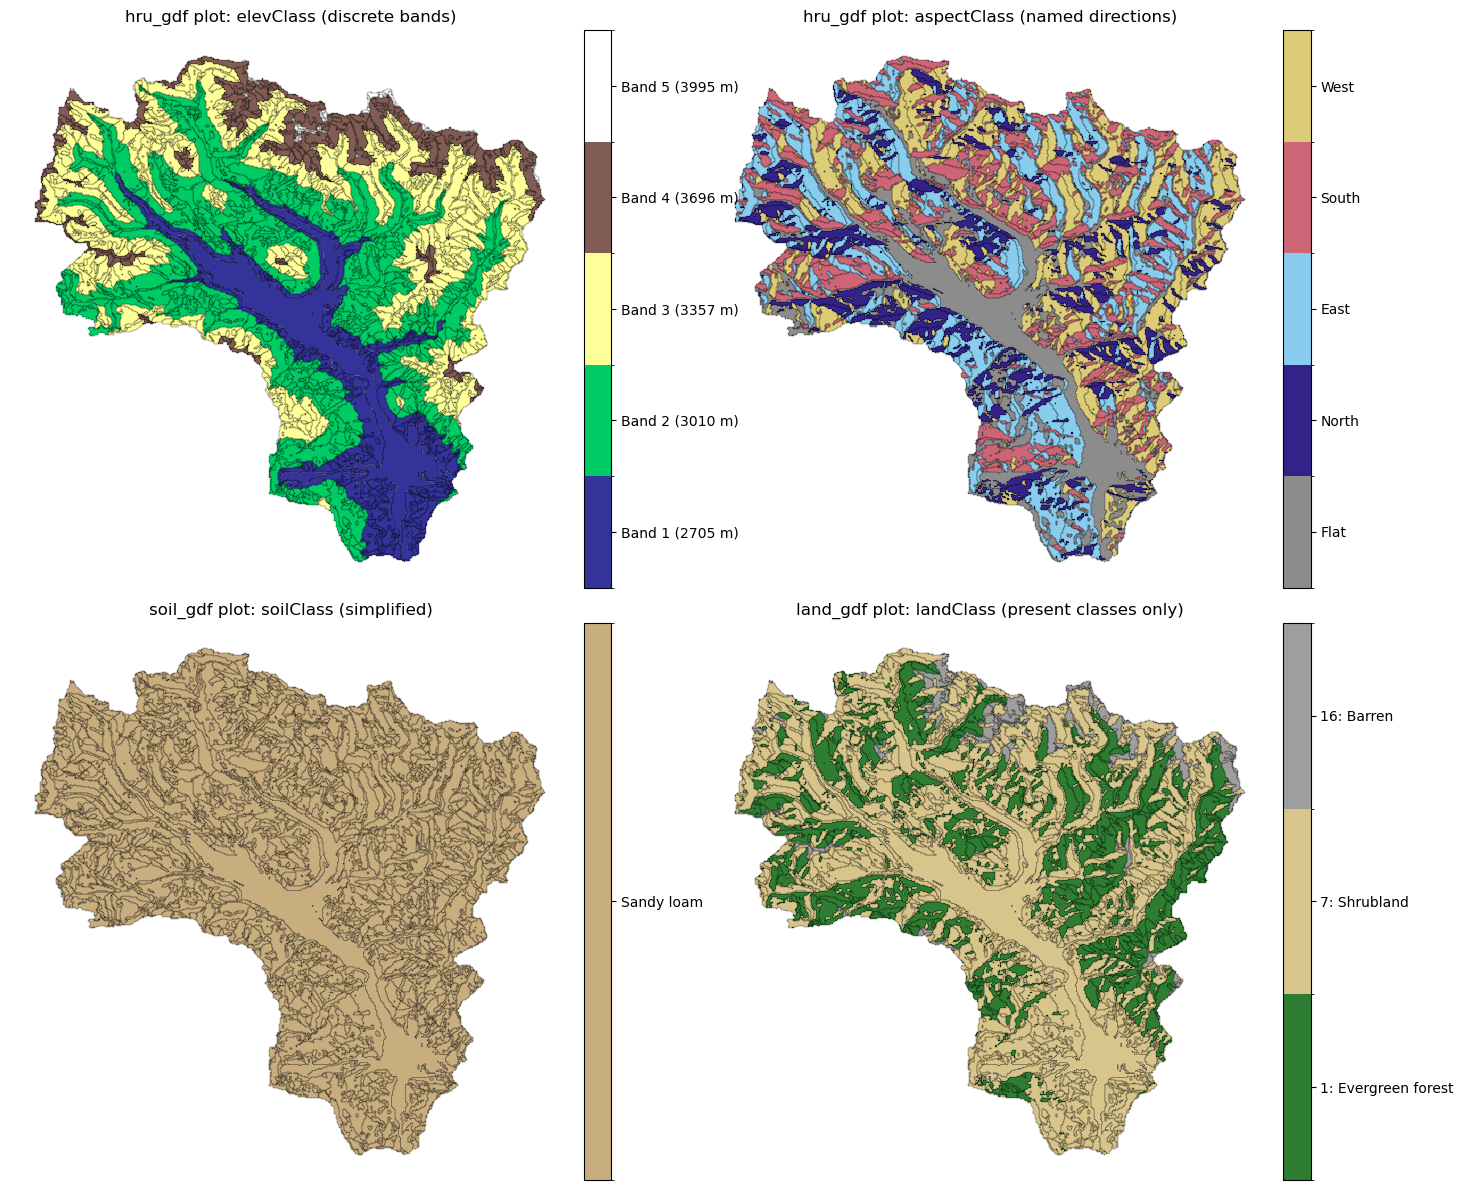

In [5]:
# Direct plots with discrete, human-readable colorbars.
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
import numpy as np


def _pick_first(cols, candidates):
    for c in candidates:
        if c in cols:
            return c
    return None


def _plot_discrete(
    ax,
    gdf,
    value_col,
    value_order,
    value_labels,
    value_colors,
    title,
    edgecolor='black',
):
    plot_gdf_local = gdf.copy()
    values = pd.to_numeric(plot_gdf_local[value_col], errors='coerce')

    value_to_idx = {v: i for i, v in enumerate(value_order)}
    plot_gdf_local['_class_idx'] = values.map(value_to_idx)

    cmap = ListedColormap(value_colors)
    norm = BoundaryNorm(np.arange(-0.5, len(value_order) + 0.5, 1), cmap.N)

    plot_gdf_local.plot(
        column='_class_idx',
        cmap=cmap,
        norm=norm,
        linewidth=0.2,
        edgecolor=edgecolor,
        ax=ax,
        legend=False,
        missing_kwds={'color': '#f0f0f0', 'edgecolor': edgecolor, 'hatch': '///', 'label': 'Missing'},
    )

    sm = ScalarMappable(norm=norm, cmap=cmap)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, ticks=np.arange(len(value_order)), fraction=0.046, pad=0.02)
    cbar.ax.set_yticklabels(value_labels)

    ax.set_title(title)
    ax.set_aspect('equal')
    ax.set_axis_off()


elev_col = _pick_first(hru_gdf.columns, ['elevClass', 'avg_elevcl', 'elev_mean'])
aspect_col = _pick_first(hru_gdf.columns, ['aspectClass', 'aspectClas'])
soil_col = _pick_first(soil_gdf.columns, ['soilClass']) if soil_gdf is not None else None
land_col = _pick_first(land_gdf.columns, ['landClass']) if land_gdf is not None else None

print('Using HRU elevation column:', elev_col)
print('Using HRU aspect column:', aspect_col)
print('Using soil column:', soil_col)
print('Using land column:', land_col)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 1) Elevation: discrete elevation-band colorbar with actual mean elevation values.
if elev_col is not None:
    elev_vals = sorted(pd.to_numeric(hru_gdf[elev_col], errors='coerce').dropna().astype(int).unique().tolist())

    elev_mean_col = _pick_first(hru_gdf.columns, ['elev_mean', 'avg_elev', 'elevation'])
    if elev_mean_col is not None:
        band_means = (
            hru_gdf[[elev_col, elev_mean_col]]
            .assign(**{elev_col: pd.to_numeric(hru_gdf[elev_col], errors='coerce')})
            .dropna()
            .groupby(elev_col)[elev_mean_col]
            .mean()
        )
        elev_labels = [f'Band {v} ({band_means.get(v, np.nan):.0f} m)' for v in elev_vals]
    else:
        elev_labels = [f'Band {v}' for v in elev_vals]

    elev_colors = [plt.get_cmap('terrain', len(elev_vals))(i) for i in range(len(elev_vals))]
    _plot_discrete(
        axes[0, 0],
        hru_gdf,
        elev_col,
        elev_vals,
        elev_labels,
        elev_colors,
        title=f'hru_gdf plot: {elev_col} (discrete bands)',
    )
else:
    axes[0, 0].text(0.5, 0.5, 'No elevation column', ha='center', va='center')
    axes[0, 0].set_axis_off()

# 2) Aspect: Flat, N, E, S, W with requested palette.
if aspect_col is not None:
    aspect_order = [0, 1, 2, 3, 4]
    aspect_labels = ['Flat', 'North', 'East', 'South', 'West']
    aspect_colors = ['#8C8C8C', '#332288', '#88CCEE', '#CC6677', '#DDCC77']

    _plot_discrete(
        axes[0, 1],
        hru_gdf,
        aspect_col,
        aspect_order,
        aspect_labels,
        aspect_colors,
        title=f'hru_gdf plot: {aspect_col} (named directions)',
    )
else:
    axes[0, 1].text(0.5, 0.5, 'No aspect column', ha='center', va='center')
    axes[0, 1].set_axis_off()

# 3) Soil: single legend entry as requested.
if soil_gdf is not None and soil_col is not None:
    soil_plot = soil_gdf.copy()
    soil_plot['_soil_single'] = 0

    _plot_discrete(
        axes[1, 0],
        soil_plot,
        '_soil_single',
        value_order=[0],
        value_labels=['Sandy loam'],
        value_colors=['#c8ad7f'],
        title=f'soil_gdf plot: {soil_col} (simplified)',
    )
else:
    axes[1, 0].text(0.5, 0.5, 'No soil layer/column', ha='center', va='center')
    axes[1, 0].set_axis_off()

# 4) Land cover: only classes present in figure with requested colors.
if land_gdf is not None and land_col is not None:
    land_values_present = sorted(pd.to_numeric(land_gdf[land_col], errors='coerce').dropna().astype(int).unique().tolist())
    # remove 15 since it is an error
    land_values_present = [v for v in land_values_present if v != 15]
    requested_land = {
        1: ('Evergreen forest', '#2e7d32'),
        7: ('Shrubland', '#d8c58b'),
        15: ('Snow and Ice', "#029ad6"),
        16: ('Barren', '#9e9e9e'),
    }


    land_order = [v for v in [1, 7,16] if v in land_values_present]
    if not land_order:
        land_order = land_values_present

    land_labels = []
    land_colors = []
    for v in land_order:
        if v in requested_land:
            label, color = requested_land[v]
        else:
            label = modis_lookup.get(v, f'Class {v}') if 'modis_lookup' in globals() else f'Class {v}'
            color = '#bdbdbd'
        land_labels.append(f'{v}: {label}')
        land_colors.append(color)

    _plot_discrete(
        axes[1, 1],
        land_gdf,
        land_col,
        land_order,
        land_labels,
        land_colors,
        title=f'land_gdf plot: {land_col} (present classes only)',
    )
else:
    axes[1, 1].text(0.5, 0.5, 'No land layer/column', ha='center', va='center')
    axes[1, 1].set_axis_off()

plt.tight_layout()
plt.show()

In [11]:
hru_gdf['slope_mean']

0     24.193674
1     24.506520
2     28.924374
3     25.733299
4      4.860701
5     25.910284
6     24.305035
7     25.184591
8     22.661936
9      5.783863
10    21.073502
11    21.206196
12    20.534953
13    20.344901
14     5.542146
15    17.424229
16    18.595263
17    18.134220
18    17.467820
19     5.439748
20    13.984145
21    13.644832
22    13.224737
23    13.618709
24     3.457155
Name: slope_mean, dtype: float64

In [6]:
# Compact table to verify ID ordering and translated classes.
show_cols = ['HRU_ID']
for c in ['elevClass', 'aspectClass', 'aspectClas', 'combined_e', 'soilClass', 'soil_name', 'landClass', 'land_name']:
    if c in hru_gdf.columns and c not in show_cols:
        show_cols.append(c)

order_df = hru_gdf[show_cols].copy()
order_df['HRU_ID'] = pd.to_numeric(order_df['HRU_ID'], errors='coerce').astype('Int64')
order_df = order_df.sort_values('HRU_ID').reset_index(drop=True)

print('Top 10 HRUs by ID:')
display(order_df.head(10))
print('Bottom 10 HRUs by ID:')
display(order_df.tail(10))

Top 10 HRUs by ID:


,HRU_ID,elevClass,aspectClass,aspectClas,combined_e,soilClass,soil_name,landClass,land_name
0,1,8,1,1,8_1,8,SANDY LOAM,16,Barren or Sparsely Vegetated
1,2,8,2,2,8_2,8,SANDY LOAM,16,Barren or Sparsely Vegetated
2,3,8,4,4,8_4,8,SANDY LOAM,16,Barren or Sparsely Vegetated
3,4,8,3,3,8_3,8,SANDY LOAM,16,Barren or Sparsely Vegetated
4,5,8,0,0,8_0,8,SANDY LOAM,16,Barren or Sparsely Vegetated
5,6,7,1,1,7_1,8,SANDY LOAM,16,Barren or Sparsely Vegetated
6,7,7,2,2,7_2,8,SANDY LOAM,16,Barren or Sparsely Vegetated
7,8,7,4,4,7_4,8,SANDY LOAM,16,Barren or Sparsely Vegetated
8,9,7,3,3,7_3,8,SANDY LOAM,16,Barren or Sparsely Vegetated
9,10,7,0,0,7_0,8,SANDY LOAM,7,Open Shrublands


Bottom 10 HRUs by ID:


,HRU_ID,elevClass,aspectClass,aspectClas,combined_e,soilClass,soil_name,landClass,land_name
31,32,2,2,2,2_2,8,SANDY LOAM,7,Open Shrublands
32,33,2,4,4,2_4,8,SANDY LOAM,1,Evergreen Needleleaf Forest
33,34,2,3,3,2_3,8,SANDY LOAM,7,Open Shrublands
34,35,2,0,0,2_0,4,LOAMY SAND,1,Evergreen Needleleaf Forest
35,36,1,1,1,1_1,8,SANDY LOAM,1,Evergreen Needleleaf Forest
36,37,1,2,2,1_2,8,SANDY LOAM,7,Open Shrublands
37,38,1,4,4,1_4,8,SANDY LOAM,1,Evergreen Needleleaf Forest
38,39,1,3,3,1_3,8,SANDY LOAM,7,Open Shrublands
39,40,1,0,0,1_0,8,SANDY LOAM,1,Evergreen Needleleaf Forest
40,41,0,1,1,0_1,4,LOAMY SAND,15,Snow and Ice


In [7]:
hru_et = pd.read_csv("/scratch/dlhogan/ess-project-data/domain_East_River_distributed_elevAspect/observations/formatted/et_per_hru.csv", index_col=0, parse_dates=['date'])
hru_et_2021 = hru_et[hru_et.index.month == 11].copy()
hru_et_2021 = hru_et_2021.rename(columns=lambda c: c.split('_')[1]).transpose()
hru_et_2021.index.name = 'HRU_ID'
hru_et_2021.index = hru_et_2021.index.astype('Int64')
hru_et_2021 = hru_et_2021.sort_index().sum(axis=1)

# map onto hru_gdf for plotting
hru_gdf_copy = hru_gdf.merge(hru_et_2021.rename('et_june'), left_on=hru_id_col, right_index=True, how='left')


aspectClas
0    97.5748
1    96.9120
2    99.9858
3    99.1726
4    98.4166
Name: et_june, dtype: float64

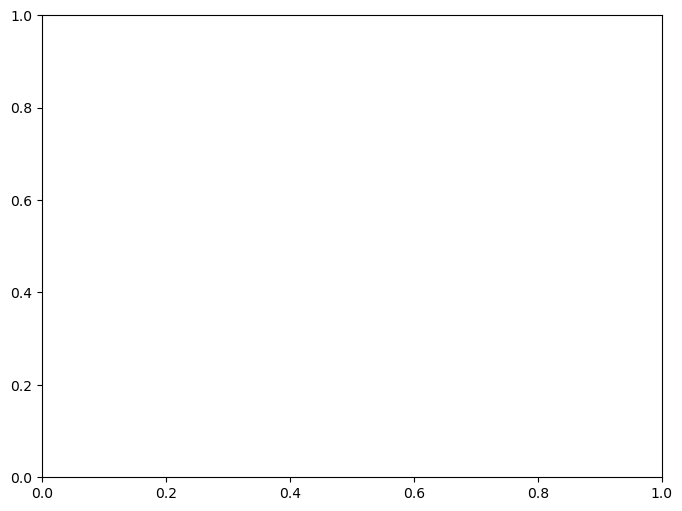

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
# plot et averaged by aspect
aspect_order = [0, 1, 2, 3, 4]
aspect_labels = ['Flat', 'North', 'East', 'South', 'West']
aspect_colors = ['#8C8C8C', '#332288', '#88CCEE', '#CC6677', '#DDCC77']

hru_gdf_copy.groupby("aspectClas")['et_june'].mean()